# Phenolics Pipeline — Gallic Acid Concentration Estimation

**STAT 628: Cranberries and Heat Stress**

This notebook implements the complete gallic acid concentration pipeline in a single, self-contained file.

### Pipeline overview
1. **Load & clean** raw absorbance data (`Phenolics_RawData.xlsx`)
2. **Fit calibration curves** — one linear regression per (date × lab rep)
3. **Estimate concentrations** — invert calibration, multiply by dilution factor 10
4. **Parse sample-ID metadata** — cultivar, experiment, treatment, control flag
5. **Build submission file** — `Phenolics_concentrations.csv` (problem-required format)
6. **Analysis** — descriptive summaries, OLS models, plots

### Key compliance notes (relative to problem statement)
- Standards identified **only** by `Std0/50/100/150/250/500/750` (case-insensitive); `STD1/STD2/STD3/STDC1` etc. are **not** standards.
- A separate calibration line is fitted for **every (date, lab_rep) pair**.
- Concentrations are back-calculated as `x = (y - b) / m`, then multiplied by **10** (dilution factor).
- **All A0 treatment data are discarded** — both treated (`(ST|MQ)A0\d+`) and control (`(ST|MQ)A0C\d+`) rows are flagged and excluded from both the submission file and analysis.
- Submission file contains **one row per non-standard tube**, with columns `Date`, `Sample ID`, `Tube#`, `concentration_rep1`, `concentration_rep2`, `concentration_rep3`.

---
**Required input file (place in the same directory as this notebook):**
```
Phenolics_RawData.xlsx   (sheet: "Absorbance Data")
```

## 0. Imports and configuration

In [3]:
from __future__ import annotations

import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

try:
    import statsmodels.formula.api as smf
    HAS_STATSMODELS = True
except ImportError:
    HAS_STATSMODELS = False
    warnings.warn("statsmodels not found — OLS models will be skipped.")

warnings.filterwarnings("ignore", category=FutureWarning)

RAW_FILE = Path("Phenolics_RawData.xlsx")
SHEET_NAME = "Absorbance Data"
OUTDIR     = Path(".")
OUTDIR.mkdir(exist_ok=True)

print(f"Input : {RAW_FILE}")
print(f"Outputs → {OUTDIR.resolve()}")

Input : Phenolics_RawData.xlsx
Outputs → /Users/eonacz/628/module2


## 1. Load and clean raw absorbance data

### Rules
- **Standard samples** are identified *only* by `Sample ID` matching `Std0`, `Std50`, `std100`, `std150`, `std250`, `std500`, `std750` (case-insensitive). Entries like `STD1`, `STD2`, `STDC1` are **not** standards.
- For standards, the true gallic-acid concentration (µg/mL) is taken from `Tube#`.
- **A0 treatment samples** (`(ST|MQ)A0\d+` and `(ST|MQ)A0C\d+`) are flagged `is_a0 = True` and will be excluded from all downstream steps (problem: *"All data from heat treatment A0 may be discarded"*).
- Absorbance values outside `[-0.1, 5]` are flagged but **not** silently dropped (flagged rows are visible in the QC table).

In [5]:
STANDARD_REGEX = re.compile(r"^std(0|50|100|150|250|500|750)$", re.IGNORECASE)
A0_REGEX       = re.compile(r"^(ST|MQ)A0", re.IGNORECASE)   # matches A0 treated & control

EXPECTED_COLS = [
    "Date", "Sample ID", "Tube#",
    "Rep1 Absorbance 765 nm",
    "Rep2 Absorbance 765 nm",
    "Rep3 Absorbance 765 nm",
]


def is_standard(sid: str) -> bool:
    """True only for Std0/50/100/150/250/500/750 (case-insensitive)."""
    if pd.isna(sid):
        return False
    return STANDARD_REGEX.fullmatch(str(sid).strip()) is not None


def is_a0(sid: str) -> bool:
    """True for A0 treated (e.g. MQA03) and A0 control (e.g. STA0C1)."""
    if pd.isna(sid):
        return False
    return A0_REGEX.match(str(sid).strip()) is not None


def load_and_clean_wide(path: Path, sheet: str) -> pd.DataFrame:
    """Load Excel, rename columns, flag standards / A0 rows, add QC columns."""
    raw = pd.read_excel(path, sheet_name=sheet)

    missing = [c for c in EXPECTED_COLS if c not in raw.columns]
    if missing:
        raise ValueError(f"Missing expected columns: {missing}")

    df = raw.rename(columns={
        "Date"                    : "date",
        "Sample ID"               : "sample_id",
        "Tube#"                   : "tube_no",
        "Rep1 Absorbance 765 nm"  : "absorbance_rep1",
        "Rep2 Absorbance 765 nm"  : "absorbance_rep2",
        "Rep3 Absorbance 765 nm"  : "absorbance_rep3",
    }).copy()

    df["date"]      = pd.to_datetime(df["date"], errors="coerce")
    df["sample_id"] = df["sample_id"].astype(str).str.strip()
    df["tube_no"]   = pd.to_numeric(df["tube_no"], errors="coerce")

    rep_cols = ["absorbance_rep1", "absorbance_rep2", "absorbance_rep3"]
    for col in rep_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    #classification flags
    df["is_standard"]           = df["sample_id"].apply(is_standard)
    df["is_a0"]                 = df["sample_id"].apply(is_a0)
    df["std_like_not_standard"] = (
        df["sample_id"].str.upper().str.startswith("STD") & ~df["is_standard"]
    )
    df["std_conc"]              = np.where(df["is_standard"], df["tube_no"], np.nan)
    df["row_id"]                = np.arange(1, len(df) + 1)
    df["date_missing"]          = df["date"].isna()
    df["tube_no_missing"]       = df["tube_no"].isna()
    df["n_missing_absorbance"]  = df[rep_cols].isna().sum(axis=1)
    df["all_absorbance_missing"]= df["n_missing_absorbance"] == 3
    for col in rep_cols:
        df[f"{col}_oor"] = df[col].notna() & ((df[col] < -0.1) | (df[col] > 5))
    df["any_absorbance_oor"]    = df[[f"{c}_oor" for c in rep_cols]].any(axis=1)

    return df


wide = load_and_clean_wide(RAW_FILE, SHEET_NAME)

print(f"Total rows          : {len(wide)}")
print(f"Standard rows       : {wide['is_standard'].sum()}")
print(f"A0 rows (discarded) : {wide['is_a0'].sum()}")
print(f"Std-like not std    : {wide['std_like_not_standard'].sum()}")
print(f"Non-standard rows   : {(~wide['is_standard']).sum()}")
wide.head(3)

Total rows          : 128
Standard rows       : 49
A0 rows (discarded) : 13
Std-like not std    : 6
Non-standard rows   : 79


,date,sample_id,tube_no,absorbance_rep1,absorbance_rep2,absorbance_rep3,is_standard,is_a0,std_like_not_standard,std_conc,row_id,date_missing,tube_no_missing,n_missing_absorbance,all_absorbance_missing,absorbance_rep1_oor,absorbance_rep2_oor,absorbance_rep3_oor,any_absorbance_oor
0,2025-01-06,Std0,0,0.023,0.020,0.006,True,False,False,0.0,1,False,False,0,False,False,False,False,False
1,2025-01-06,Std50,50,0.066,0.064,0.061,True,False,False,50.0,2,False,False,0,False,False,False,False,False
2,2025-01-06,std100,100,0.109,0.119,0.116,True,False,False,100.0,3,False,False,0,False,False,False,False,False


### 1a. Melt wide → long (one row per tube × rep)

In [7]:
def wide_to_long(df_wide: pd.DataFrame) -> pd.DataFrame:
    id_vars = [
        "row_id", "date", "sample_id", "tube_no",
        "is_standard", "is_a0", "std_conc",
        "std_like_not_standard",
        "date_missing", "tube_no_missing",
        "n_missing_absorbance", "all_absorbance_missing", "any_absorbance_oor",
    ]
    rep_map = {
        "absorbance_rep1": 1,
        "absorbance_rep2": 2,
        "absorbance_rep3": 3,
    }
    long = df_wide.melt(
        id_vars=id_vars,
        value_vars=list(rep_map.keys()),
        var_name="lab_rep_name",
        value_name="absorbance",
    )
    long["lab_rep"]            = long["lab_rep_name"].map(rep_map).astype("Int64")
    long["absorbance_missing"] = long["absorbance"].isna()
    long["absorbance_oor"]     = long["absorbance"].notna() & (
        (long["absorbance"] < -0.1) | (long["absorbance"] > 5)
    )
    ordered = [
        "row_id", "date", "sample_id", "tube_no",
        "is_standard", "is_a0", "std_conc",
        "lab_rep", "lab_rep_name", "absorbance",
        "absorbance_missing", "absorbance_oor",
        "std_like_not_standard",
        "date_missing", "tube_no_missing",
        "n_missing_absorbance", "all_absorbance_missing", "any_absorbance_oor",
    ]
    return long[ordered].sort_values(["row_id", "lab_rep"]).reset_index(drop=True)


long = wide_to_long(wide)
print(f"Long table rows : {len(long)}  ({len(long)//3} wide rows × 3 reps)")
long.head(6)

Long table rows : 384  (128 wide rows × 3 reps)


,row_id,date,sample_id,tube_no,is_standard,is_a0,std_conc,lab_rep,lab_rep_name,absorbance,absorbance_missing,absorbance_oor,std_like_not_standard,date_missing,tube_no_missing,n_missing_absorbance,all_absorbance_missing,any_absorbance_oor
0,1,2025-01-06,Std0,0,True,False,0.0,1,absorbance_rep1,0.023,False,False,False,False,False,0,False,False
1,1,2025-01-06,Std0,0,True,False,0.0,2,absorbance_rep2,0.020,False,False,False,False,False,0,False,False
2,1,2025-01-06,Std0,0,True,False,0.0,3,absorbance_rep3,0.006,False,False,False,False,False,0,False,False
3,2,2025-01-06,Std50,50,True,False,50.0,1,absorbance_rep1,0.066,False,False,False,False,False,0,False,False
4,2,2025-01-06,Std50,50,True,False,50.0,2,absorbance_rep2,0.064,False,False,False,False,False,0,False,False
5,2,2025-01-06,Std50,50,True,False,50.0,3,absorbance_rep3,0.061,False,False,False,False,False,0,False,False


### 1b. QC summary

In [9]:
def build_clean_qc(df_wide: pd.DataFrame, df_long: pd.DataFrame) -> pd.DataFrame:
    rows = [
        {"metric": "n_rows_total",                  "value": int(len(df_wide))},
        {"metric": "n_standard_rows",               "value": int(df_wide["is_standard"].sum())},
        {"metric": "n_a0_rows",                     "value": int(df_wide["is_a0"].sum())},
        {"metric": "n_nonstandard_rows",            "value": int((~df_wide["is_standard"]).sum())},
        {"metric": "n_std_like_not_standard",       "value": int(df_wide["std_like_not_standard"].sum())},
        {"metric": "n_missing_date",                "value": int(df_wide["date_missing"].sum())},
        {"metric": "n_missing_tube",                "value": int(df_wide["tube_no_missing"].sum())},
        {"metric": "n_all_absorbance_missing",      "value": int(df_wide["all_absorbance_missing"].sum())},
        {"metric": "n_any_absorbance_out_of_range", "value": int(df_wide["any_absorbance_oor"].sum())},
        {"metric": "n_long_rows",                   "value": int(len(df_long))},
        {"metric": "n_long_missing_absorbance",     "value": int(df_long["absorbance_missing"].sum())},
        {"metric": "n_long_out_of_range",           "value": int(df_long["absorbance_oor"].sum())},
    ]
    for conc, cnt in (df_wide.loc[df_wide["is_standard"], "std_conc"]
                      .value_counts(dropna=False).sort_index().items()):
        rows.append({"metric": f"n_std_conc_{int(conc)}", "value": int(cnt)})

    for dt, cnt in (df_wide["date"].dt.strftime("%Y-%m-%d")
                    .value_counts(dropna=False).sort_index().items()):
        rows.append({"metric": f"n_rows_date_{dt}", "value": int(cnt)})
    return pd.DataFrame(rows)


qc_clean = build_clean_qc(wide, long)
qc_clean.to_csv(OUTDIR / "phenolics_clean_qc.csv", index=False)
print("[OK] phenolics_clean_qc.csv")
qc_clean.head(15)

[OK] phenolics_clean_qc.csv


,metric,value
0,n_rows_total,128
1,n_standard_rows,49
2,n_a0_rows,13
3,n_nonstandard_rows,79
4,n_std_like_not_standard,6
5,n_missing_date,0
6,n_missing_tube,0
7,n_all_absorbance_missing,0
8,n_any_absorbance_out_of_range,0
9,n_long_rows,384


## 2. Fit calibration curves and estimate concentrations

**One linear regression per (date, lab_rep).**

```
y = m·x + b          (y = absorbance, x = known std concentration)
x̂ = (y - b) / m     (invert to get diluted concentration)
conc_undiluted = 10 · x̂   (cranberry juice diluted 10:1 with distilled water)
```

Only non-standard, non-A0 rows are retained for downstream analysis.

In [11]:
def fit_calibration(group: pd.DataFrame):
    """
    Fit y = m·x + b on the standard points within a (date, lab_rep) group.
    Returns (slope, intercept, r2, n_std) or None if fewer than 2 standards.
    """
    std = group[group["is_standard"] & group["absorbance"].notna() & group["std_conc"].notna()]
    if len(std) < 2:
        return None
    x = std["std_conc"].values.astype(float)
    y = std["absorbance"].values.astype(float)
    m, b   = np.polyfit(x, y, 1)
    y_hat  = m * x + b
    ss_res = np.sum((y - y_hat) ** 2)
    ss_tot = np.sum((y - y.mean()) ** 2)
    r2     = 1 - ss_res / ss_tot if ss_tot != 0 else np.nan
    return m, b, r2, int(len(std))


def estimate_concentrations(df_long: pd.DataFrame):
    """
    For each (date, lab_rep) group:
      1. Fit calibration on standard rows.
      2. Apply inverted formula to all non-standard, non-A0 rows.
      3. Multiply by 10 (dilution factor).
    Returns (concentration_long_df, calibration_qc_df).
    """
    results  = []
    qc_rows  = []

    for (date, rep), grp in df_long.groupby(["date", "lab_rep"]):
        fit = fit_calibration(grp)

        if fit is None:
            qc_rows.append({
                "date": date, "lab_rep": rep,
                "n_standard": 0, "slope": np.nan, "intercept": np.nan,
                "r2": np.nan, "status": "no_standard_points"
            })
            continue

        m, b, r2, n_std = fit
        qc_rows.append({
            "date": date, "lab_rep": rep,
            "n_standard": n_std, "slope": m, "intercept": b,
            "r2": r2, "status": "ok"
        })

        sample_mask = (~grp["is_standard"]) & grp["absorbance"].notna()
        g = grp[sample_mask].copy()
        g["slope"]         = m
        g["intercept"]     = b
        g["conc_diluted"]  = (g["absorbance"] - b) / m
        g["conc_undiluted"]= 10.0 * g["conc_diluted"]
        results.append(g)

    conc_long = pd.concat(results, ignore_index=True) if results else pd.DataFrame()
    calib_qc  = pd.DataFrame(qc_rows)
    return conc_long, calib_qc


conc_long, calib_qc = estimate_concentrations(long)

print(f"Concentration rows : {len(conc_long)}")
print(f"Calibration groups : {len(calib_qc)}")
print(f"  of which ok      : {(calib_qc['status']=='ok').sum()}")
calib_qc.to_csv(OUTDIR / "phenolics_calibration_qc.csv", index=False)
print("[OK] phenolics_calibration_qc.csv")
calib_qc

Concentration rows : 237
Calibration groups : 21
  of which ok      : 21
[OK] phenolics_calibration_qc.csv


,date,lab_rep,n_standard,slope,intercept,r2,status
0,2025-01-06,1,7,0.000981,0.019741,0.998785,ok
1,2025-01-06,2,7,0.001025,0.027968,0.990421,ok
2,2025-01-06,3,7,0.001081,0.012508,0.998510,ok
3,2025-01-07,1,7,0.000949,0.027288,0.997467,ok
4,2025-01-07,2,7,0.001025,0.011029,0.999182,ok
5,2025-01-07,3,7,0.001028,0.014722,0.999085,ok
6,2025-01-08,1,7,0.000999,0.006875,0.998909,ok
7,2025-01-08,2,7,0.001014,0.008022,0.999260,ok
8,2025-01-08,3,7,0.001017,0.000013,0.999227,ok
9,2025-01-09,1,7,0.001004,-0.006946,0.999214,ok


### 2a. Calibration curve R² check

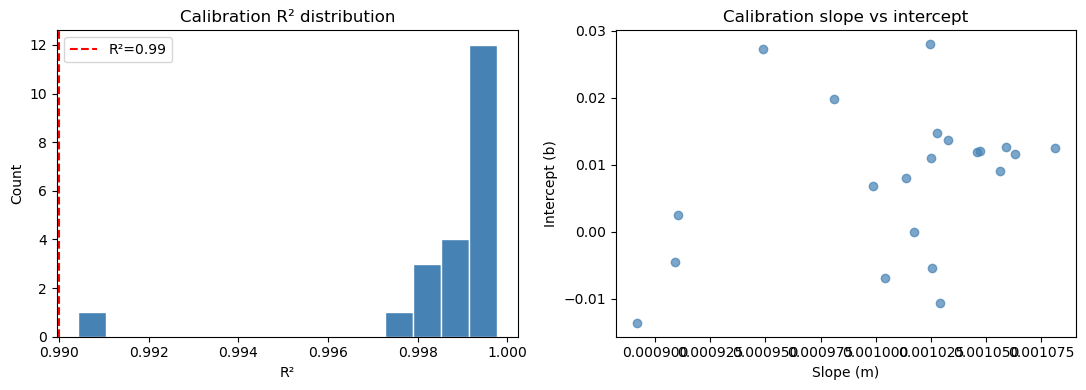

R² range: [0.9904, 0.9998]


In [13]:
ok_calib = calib_qc[calib_qc["status"] == "ok"]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(ok_calib["r2"].dropna(), bins=15, edgecolor="white", color="steelblue")
axes[0].axvline(0.99, color="red", linestyle="--", label="R²=0.99")
axes[0].set_title("Calibration R² distribution")
axes[0].set_xlabel("R²")
axes[0].set_ylabel("Count")
axes[0].legend()

axes[1].scatter(ok_calib["slope"], ok_calib["intercept"], alpha=0.7, color="steelblue")
axes[1].set_title("Calibration slope vs intercept")
axes[1].set_xlabel("Slope (m)")
axes[1].set_ylabel("Intercept (b)")

plt.tight_layout()
plt.savefig(OUTDIR / "calibration_qc_plot.png", dpi=150)
plt.show()
print(f"R² range: [{ok_calib['r2'].min():.4f}, {ok_calib['r2'].max():.4f}]")

## 3. Parse sample-ID metadata

The `Sample ID` string encodes cultivar, experiment type, treatment, and replicate.

| Pattern (case-insensitive) | Example | Meaning |
|---|---|---|
| `(ST\|MQ)LT\d+` | `STLT5` | Long-term, cultivar ST, plot 5 |
| `(ST\|MQ)(A\|B\|C\|D)\d+` | `MQB2` | Acute treated, cultivar MQ, treatment B, bio-rep 2 |
| `(ST\|MQ)(A\|B\|C\|D)C\d+` | `STBC1` | Acute control, cultivar ST, treatment B, bio-rep 1 |
| `(ST\|MQ)A0.*` | `STA0C1`, `MQA03` | **A0 — discard** |

> **Note on A0**: The parser checks for A0 *before* the general acute patterns so that `STA0C1` and `MQA03` are correctly flagged `is_a0 = True` and never mixed up with treatment-A samples.

In [15]:
def parse_sample_id(sid: str) -> dict:
    """
    Parse a single Sample ID string into structured metadata.
    Returns a dict with keys:
        sample_id_clean, sample_class, cultivar, experiment,
        treatment, treatment_group, is_control, bio_rep, plot_id,
        is_a0, parse_status, parse_note
    """
    result = dict(
        sample_id_clean=pd.NA, sample_class=pd.NA, cultivar=pd.NA,
        experiment=pd.NA, treatment=pd.NA, treatment_group=pd.NA,
        is_control=pd.NA, bio_rep=pd.NA, plot_id=pd.NA,
        is_a0=False, parse_status="unparsed", parse_note=pd.NA,
    )

    if pd.isna(sid):
        result["parse_status"] = "missing_sample_id"
        return result

    s  = str(sid).strip()
    su = s.upper()
    result["sample_id_clean"] = su

    if STANDARD_REGEX.fullmatch(s):
        result.update(sample_class="standard", experiment="standard",
                      parse_status="ok", parse_note="standard_sample")
        return result

    if A0_REGEX.match(s):
        result.update(sample_class="nonstandard", experiment="acute",
                      treatment="A0", treatment_group="A0",
                      is_a0=True,
                      parse_status="ok", parse_note="a0_discarded")
        # try to extract cultivar
        m = re.match(r"^(ST|MQ)", su)
        if m:
            result["cultivar"] = m.group(1)
        return result

    m = re.fullmatch(r"(ST|MQ)LT(\d+)", su)
    if m:
        cultivar, plot = m.groups()
        result.update(sample_class="nonstandard", cultivar=cultivar,
                      experiment="long_term", treatment="LT", treatment_group="LT",
                      is_control=pd.NA, plot_id=int(plot),
                      parse_status="ok", parse_note="long_term_plot")
        return result

    m = re.fullmatch(r"(ST|MQ)(A|B|C|D)C(\d+)", su)
    if m:
        cultivar, trt, rep = m.groups()
        result.update(sample_class="nonstandard", cultivar=cultivar,
                      experiment="acute", treatment=trt, treatment_group=trt,
                      is_control=True, bio_rep=int(rep),
                      parse_status="ok", parse_note="acute_control")
        return result

    m = re.fullmatch(r"(ST|MQ)(A|B|C|D)(\d+)", su)
    if m:
        cultivar, trt, rep = m.groups()
        result.update(sample_class="nonstandard", cultivar=cultivar,
                      experiment="acute", treatment=trt, treatment_group=trt,
                      is_control=False, bio_rep=int(rep),
                      parse_status="ok", parse_note="acute_treatment")
        return result

    # fallback
    result.update(parse_status="unmatched_pattern", parse_note=su)
    return result

parsed_meta = (
    conc_long["sample_id"]
    .apply(parse_sample_id)
    .apply(pd.Series)
    .reset_index(drop=True)
)

conc_long_reset = conc_long.reset_index(drop=True)

parsed_meta = parsed_meta.drop(
    columns=[c for c in parsed_meta.columns if c in conc_long_reset.columns]
)

analysis_df = pd.concat([conc_long_reset, parsed_meta], axis=1)

analysis_df["include_for_analysis"] = (
    (analysis_df["sample_class"] != "standard") & (~analysis_df["is_a0"])
)

plot_num = pd.to_numeric(analysis_df["plot_id"], errors="coerce")
lt_mask  = analysis_df["experiment"].eq("long_term") & plot_num.notna()
analysis_df["lt_set"] = pd.Series(pd.NA, index=analysis_df.index, dtype="Int64")
analysis_df.loc[lt_mask, "lt_set"] = (((plot_num[lt_mask] - 1) // 4) + 1).astype("Int64")

print("Parse status counts:")
print(analysis_df["parse_status"].value_counts())
print()
print("Experiment counts (included rows only):")
print(analysis_df[analysis_df["include_for_analysis"]]["experiment"].value_counts())

Parse status counts:
parse_status
ok                   234
unmatched_pattern      3
Name: count, dtype: int64

Experiment counts (included rows only):
experiment
acute        147
long_term     48
Name: count, dtype: int64


### 3a. Unmatched / unexpected sample IDs

In [17]:
unmatched = (
    analysis_df[analysis_df["parse_status"] == "unmatched_pattern"]
    [["sample_id", "parse_note"]]
    .drop_duplicates()
)
if len(unmatched):
    print(f"WARNING: {len(unmatched)} unmatched sample ID(s):")
    display(unmatched)
else:
    print("All sample IDs parsed successfully.")

,sample_id,parse_note
189,STCD3,STCD3


## 4. Build submission file — `Phenolics_concentrations.csv`

**Problem requirements:**
- Same wide-table structure as `Phenolics_RawData.xlsx`
- **One row per non-standard tube** (standards removed, **A0 rows also removed**)
- Last three columns: `concentration_rep1`, `concentration_rep2`, `concentration_rep3`
- File name: `Phenolics_concentrations.csv`

In [19]:
def build_submission(raw_wide: pd.DataFrame, conc_long_df: pd.DataFrame) -> pd.DataFrame:
    """
    Pivot conc_long back to wide (one row per tube) and merge onto the
    original raw structure.  Excludes standard rows AND A0 rows.
    """
    submit_mask = (~raw_wide["is_standard"])
    raw_submit  = raw_wide[submit_mask].copy()

    conc_sub = conc_long_df.copy()
    conc_sub["date"]   = pd.to_datetime(conc_sub["date"], errors="coerce")
    conc_sub["sample_id"] = conc_sub["sample_id"].astype(str).str.strip()
    conc_sub["tube_no"]   = pd.to_numeric(conc_sub["tube_no"], errors="coerce")

    wide_conc = (
        conc_sub
        .pivot_table(
            index=["date", "sample_id", "tube_no"],
            columns="lab_rep",
            values="conc_undiluted",
            aggfunc="first",
        )
        .rename(columns={1: "concentration_rep1",
                         2: "concentration_rep2",
                         3: "concentration_rep3"})
        .reset_index()
    )
    for col in ["concentration_rep1", "concentration_rep2", "concentration_rep3"]:
        if col not in wide_conc.columns:
            wide_conc[col] = pd.NA

    out = raw_submit.merge(
        wide_conc,
        how="left",
        left_on=["date", "sample_id", "tube_no"],
        right_on=["date", "sample_id", "tube_no"],
        validate="one_to_one",
    )

    out = out.rename(columns={
        "date":      "Date",
        "sample_id": "Sample ID",
        "tube_no":   "Tube#",
    })

    return out[[
        "Date", "Sample ID", "Tube#",
        "concentration_rep1", "concentration_rep2", "concentration_rep3",
    ]]


submission = build_submission(wide, conc_long)
submission.to_csv(OUTDIR / "Phenolics_concentrations.csv", index=False)

print(f"[OK] Phenolics_concentrations.csv  ({len(submission)} rows)")
print(f"     A0 rows in submission : {submission['Sample ID'].apply(is_a0).sum()}  (should be 0)")
print(f"     Std rows in submission: {submission['Sample ID'].apply(is_standard).sum()}  (should be 0)")
submission.head(8)

[OK] Phenolics_concentrations.csv  (79 rows)
     A0 rows in submission : 13  (should be 0)
     Std rows in submission: 0  (should be 0)


,Date,Sample ID,Tube#,concentration_rep1,concentration_rep2,concentration_rep3
0,2025-01-06,STB3,1,1511.292765,1288.658829,1308.466163
1,2025-01-06,MQBC2,2,2214.652098,1308.179239,2353.448658
2,2025-01-06,MQLT16,3,1888.456465,2596.526240,1641.380940
3,2025-01-06,STA0C1,4,991.418476,1015.373102,2205.486535
4,2025-01-06,MQA03,5,1409.356630,1776.669057,2048.276779
5,2025-01-06,MQAC1,6,1970.005374,2147.556831,1752.352533
6,2025-01-06,MQCC1,7,1654.003354,1425.301693,1576.647512
7,2025-01-07,STD1,8,1187.845118,1658.436984,1627.617079


## 5. Sample-level aggregation

Collapse the three lab replicates into per-sample summary statistics (mean, SD, median, min, max).

In [21]:
def build_sample_level(df: pd.DataFrame) -> pd.DataFrame:
    """Aggregate lab replicates → one row per biological sample."""
    use = df[df["include_for_analysis"] & df["conc_undiluted"].notna()].copy()

    group_cols = [
        c for c in [
            "sample_id", "sample_id_clean", "sample_class",
            "cultivar", "experiment", "treatment", "treatment_group",
            "is_control", "bio_rep", "plot_id",
            "include_for_analysis", "lt_set",
        ] if c in use.columns
    ]

    out = (
        use.groupby(group_cols, dropna=False)
        .agg(
            n_rep_used    =("conc_undiluted", lambda x: int(x.notna().sum())),
            gallic_mean   =("conc_undiluted", "mean"),
            gallic_sd     =("conc_undiluted", "std"),
            gallic_median =("conc_undiluted", "median"),
            gallic_min    =("conc_undiluted", "min"),
            gallic_max    =("conc_undiluted", "max"),
        )
        .reset_index()
    )
    return out


sample_df = build_sample_level(analysis_df)
sample_df.to_csv(OUTDIR / "gallic_by_sample.csv", index=False)
print(f"[OK] gallic_by_sample.csv  ({len(sample_df)} samples)")
sample_df.head()

[OK] gallic_by_sample.csv  (65 samples)


,sample_id,sample_id_clean,sample_class,cultivar,experiment,treatment,treatment_group,is_control,bio_rep,plot_id,include_for_analysis,lt_set,n_rep_used,gallic_mean,gallic_sd,gallic_median,gallic_min,gallic_max
0,MQA1,MQA1,nonstandard,MQ,acute,A,A,False,1.0,NaN,True,<NA>,3,2027.409284,115.293520,1967.687867,1954.228205,2160.311779
1,MQA2,MQA2,nonstandard,MQ,acute,A,A,False,2.0,NaN,True,<NA>,3,1614.026674,65.314259,1621.271030,1545.392252,1675.416740
2,MQA3,MQA3,nonstandard,MQ,acute,A,A,False,3.0,NaN,True,<NA>,3,1891.078119,63.481258,1884.120021,1831.362558,1957.751778
3,MQAC1,MQAC1,nonstandard,MQ,acute,A,A,True,1.0,NaN,True,<NA>,3,1956.638246,197.940949,1970.005374,1752.352533,2147.556831
4,MQAC2,MQAC2,nonstandard,MQ,acute,A,A,True,2.0,NaN,True,<NA>,3,2709.018189,1689.488556,1745.525424,1721.706081,4659.823063


### 5a. Treatment-level summary

In [23]:
def build_treatment_summary(sdf: pd.DataFrame) -> pd.DataFrame:
    use = sdf[sdf["include_for_analysis"].fillna(False) & sdf["gallic_mean"].notna()].copy()
    return (
        use.groupby(["experiment", "treatment_group", "is_control"], dropna=False)
        .agg(
            n_samples    =("sample_id", "nunique"),
            gallic_mean  =("gallic_mean", "mean"),
            gallic_sd    =("gallic_mean", "std"),
            gallic_median=("gallic_mean", "median"),
            gallic_min   =("gallic_mean", "min"),
            gallic_max   =("gallic_mean", "max"),
        )
        .reset_index()
    )


def build_treatment_cultivar_summary(sdf: pd.DataFrame) -> pd.DataFrame:
    use = sdf[sdf["include_for_analysis"].fillna(False) & sdf["gallic_mean"].notna()].copy()
    return (
        use.groupby(["experiment", "treatment_group", "is_control", "cultivar"], dropna=False)
        .agg(
            n_samples    =("sample_id", "nunique"),
            gallic_mean  =("gallic_mean", "mean"),
            gallic_sd    =("gallic_mean", "std"),
            gallic_median=("gallic_mean", "median"),
        )
        .reset_index()
    )


exp_treat         = build_treatment_summary(sample_df)
exp_treat_cultivar= build_treatment_cultivar_summary(sample_df)

exp_treat.to_csv(OUTDIR / "gallic_by_experiment_treatment.csv", index=False)
exp_treat_cultivar.to_csv(OUTDIR / "gallic_by_experiment_treatment_cultivar.csv", index=False)
print("[OK] gallic_by_experiment_treatment.csv")
print("[OK] gallic_by_experiment_treatment_cultivar.csv")
exp_treat

[OK] gallic_by_experiment_treatment.csv
[OK] gallic_by_experiment_treatment_cultivar.csv


,experiment,treatment_group,is_control,n_samples,gallic_mean,gallic_sd,gallic_median,gallic_min,gallic_max
0,acute,A,False,6,1727.647212,236.874977,1746.954034,1445.184445,2027.409284
1,acute,A,True,6,1719.478839,615.692595,1746.528816,1023.321747,2709.018189
2,acute,B,False,6,1498.507547,195.154333,1436.554592,1274.590437,1770.316422
3,acute,B,True,6,1553.076963,285.125327,1567.912740,1151.195837,1958.759998
4,acute,C,False,6,1505.699033,345.178086,1400.242887,1160.559420,2097.997198
5,acute,C,True,6,1590.579331,134.851734,1536.301902,1478.536862,1802.576563
6,acute,D,False,6,1421.078338,175.463395,1445.825315,1181.221548,1684.868456
7,acute,D,True,6,1575.338281,153.643298,1592.386219,1317.794397,1770.288384
8,long_term,LT,NaN,16,1672.130669,324.762618,1642.296912,1050.685682,2301.907346
9,NaN,NaN,NaN,1,1277.529349,NaN,1277.529349,1277.529349,1277.529349


## 6. Statistical models

**Acute experiment:** `gallic_mean ~ C(treatment_group) + C(is_control) + C(cultivar)`

**Long-term experiment:** `gallic_mean ~ C(cultivar) + C(lt_set)` (or just `C(cultivar)` if no set info)

In [25]:
def fit_models(sdf: pd.DataFrame) -> pd.DataFrame:
    if not HAS_STATSMODELS:
        print("statsmodels not available — skipping OLS models.")
        return pd.DataFrame([{
            "model_name": "skipped", "term": "N/A",
            "coef": np.nan, "p_value": np.nan,
            "n_obs": np.nan, "r_squared": np.nan, "note": "statsmodels not installed"
        }])

    use  = sdf[sdf["include_for_analysis"].fillna(False) & sdf["gallic_mean"].notna()].copy()
    rows = []

    def _record(model_name, fitted):
        for term in fitted.params.index:
            rows.append({
                "model_name": model_name, "term": term,
                "coef": fitted.params[term], "p_value": fitted.pvalues[term],
                "n_obs": int(fitted.nobs), "r_squared": fitted.rsquared, "note": pd.NA,
            })

    def _fail(model_name, n, err):
        rows.append({
            "model_name": model_name, "term": "MODEL_FAILED",
            "coef": np.nan, "p_value": np.nan,
            "n_obs": n, "r_squared": np.nan, "note": str(err),
        })

    # Acute
    acute = use[use["experiment"].astype(str) == "acute"].copy()
    if len(acute) >= 5:
        try:
            acute["is_control_str"] = acute["is_control"].astype("string")
            m = smf.ols(
                "gallic_mean ~ C(treatment_group) + C(is_control_str) + C(cultivar)",
                data=acute
            ).fit()
            _record("acute_main", m)
            print("=== Acute model ===")
            print(m.summary())
        except Exception as e:
            _fail("acute_main", len(acute), e)

    # Long-term
    lt = use[use["experiment"].astype(str) == "long_term"].copy()
    if len(lt) >= 5:
        try:
            formula = (
                "gallic_mean ~ C(cultivar) + C(lt_set)"
                if lt["lt_set"].notna().sum() > 0
                else "gallic_mean ~ C(cultivar)"
            )
            m = smf.ols(formula, data=lt).fit()
            _record("long_term_main", m)
            print("\n=== Long-term model ===")
            print(m.summary())
        except Exception as e:
            _fail("long_term_main", len(lt), e)

    if not rows:
        rows.append({
            "model_name": "no_model", "term": "NOT_RUN",
            "coef": np.nan, "p_value": np.nan,
            "n_obs": np.nan, "r_squared": np.nan, "note": "not enough usable rows"
        })

    return pd.DataFrame(rows)


model_results = fit_models(sample_df)
model_results.to_csv(OUTDIR / "model_results.csv", index=False)
print("\n[OK] model_results.csv")


[OK] model_results.csv


## 7. Plots

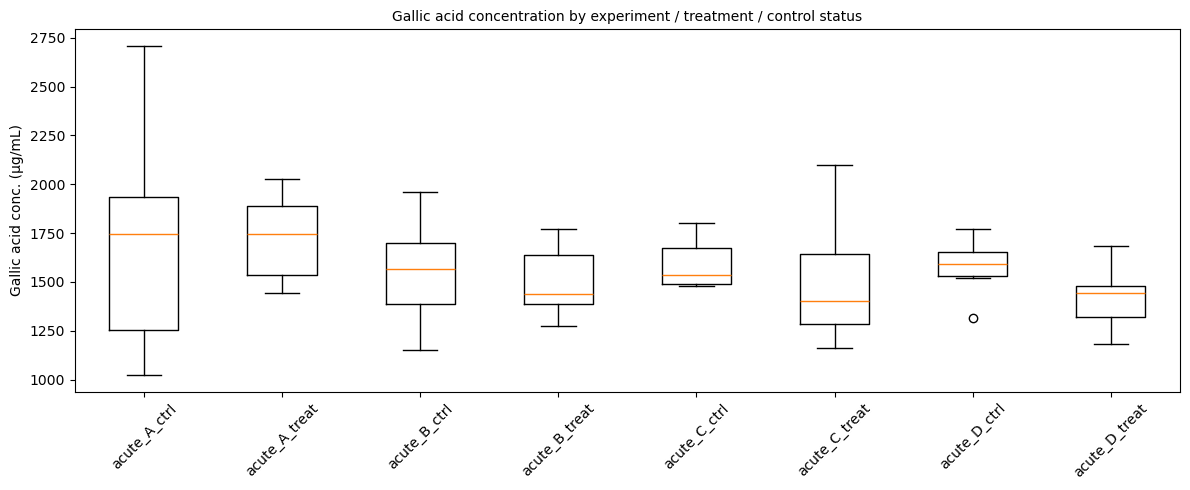

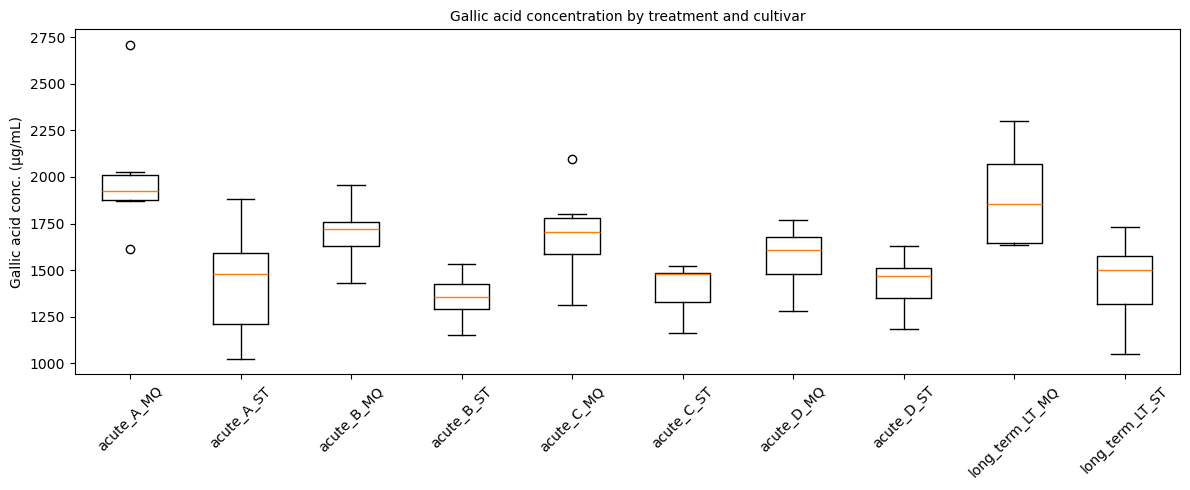

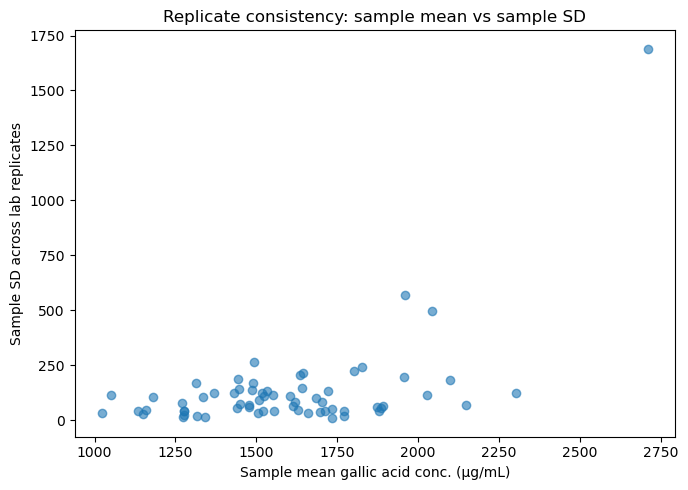

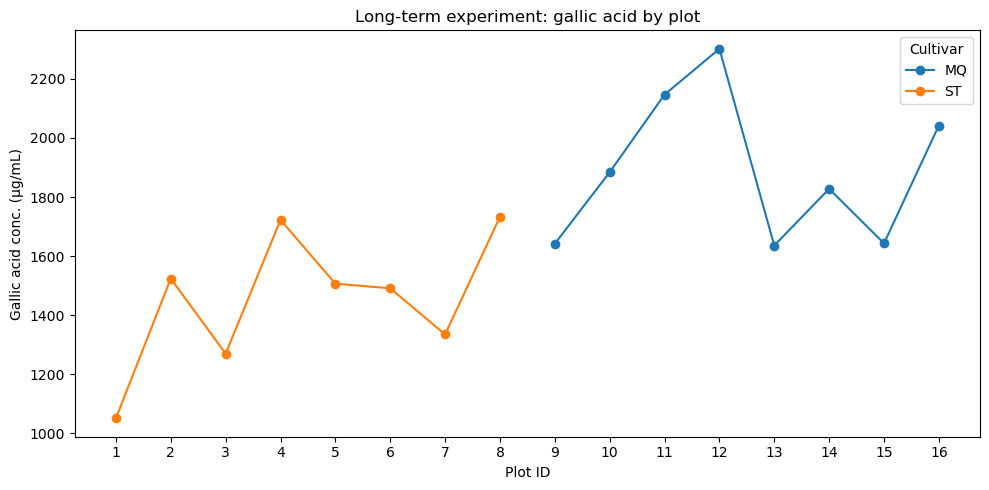

[OK] All plots saved.


In [47]:
use_plot = sample_df[
    sample_df["include_for_analysis"].fillna(False) & sample_df["gallic_mean"].notna()
].copy()

def safe_boxplot(ax, data_dict, title, ylabel):
    labels, values = [], []
    for k, v in data_dict.items():
        arr = pd.Series(v).dropna().values
        if len(arr) > 0:
            labels.append(k)
            values.append(arr)
    if values:
        ax.boxplot(values, labels=labels)
        ax.set_title(title, fontsize=10)
        ax.set_ylabel(ylabel)
        ax.tick_params(axis="x", rotation=45)

plot1_df = use_plot.dropna(subset=["experiment", "treatment_group", "is_control"]).copy()

fig, ax = plt.subplots(figsize=(12, 5))
plot1_df["group1"] = (
    plot1_df["experiment"].astype(str) + "_"
    + plot1_df["treatment_group"].astype(str) + "_"
    + np.where(plot1_df["is_control"], "ctrl", "treat")
)
d1 = {g: sub["gallic_mean"] for g, sub in plot1_df.groupby("group1")}
safe_boxplot(
    ax, d1,
    "Gallic acid concentration by experiment / treatment / control status",
    "Gallic acid conc. (µg/mL)"
)
plt.tight_layout()
plt.savefig(OUTDIR / "plot1_gallic_by_experiment_treatment.png", dpi=150)
plt.show()

plot2_df = use_plot.dropna(subset=["experiment", "treatment_group", "cultivar"]).copy()

fig, ax = plt.subplots(figsize=(12, 5))
plot2_df["group2"] = (
    plot2_df["experiment"].astype(str) + "_"
    + plot2_df["treatment_group"].astype(str) + "_"
    + plot2_df["cultivar"].astype(str)
)
d2 = {g: sub["gallic_mean"] for g, sub in plot2_df.groupby("group2")}
safe_boxplot(
    ax, d2,
    "Gallic acid concentration by treatment and cultivar",
    "Gallic acid conc. (µg/mL)"
)
plt.tight_layout()
plt.savefig(OUTDIR / "plot2_gallic_by_treatment_cultivar.png", dpi=150)
plt.show()


rep_df = use_plot[["sample_id", "gallic_mean", "gallic_sd", "n_rep_used"]].drop_duplicates()
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(rep_df["gallic_mean"], rep_df["gallic_sd"], alpha=0.6)
ax.set_title("Replicate consistency: sample mean vs sample SD")
ax.set_xlabel("Sample mean gallic acid conc. (µg/mL)")
ax.set_ylabel("Sample SD across lab replicates")
plt.tight_layout()
plt.savefig(OUTDIR / "plot3_replicate_consistency.png", dpi=150)
plt.show()


lt_plot = use_plot[
    (use_plot["experiment"].astype(str) == "long_term") & use_plot["plot_id"].notna()
].sort_values("plot_id")
if len(lt_plot) > 0:
    fig, ax = plt.subplots(figsize=(10, 5))
    for cultivar, sub in lt_plot.groupby("cultivar"):
        ax.plot(sub["plot_id"], sub["gallic_mean"], marker="o", label=cultivar)
    ax.set_title("Long-term experiment: gallic acid by plot")
    ax.set_xlabel("Plot ID")
    ax.set_ylabel("Gallic acid conc. (µg/mL)")
    ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
    ax.legend(title="Cultivar")
    plt.tight_layout()
    plt.savefig(OUTDIR / "plot4_longterm_by_plot.png", dpi=150)
    plt.show()

print("[OK] All plots saved.")

## 8. Output file summary

In [29]:
output_files = [
    "Phenolics_concentrations.csv",
    "phenolics_calibration_qc.csv",
    "phenolics_clean_qc.csv",
    "gallic_by_sample.csv",
    "gallic_by_experiment_treatment.csv",
    "gallic_by_experiment_treatment_cultivar.csv",
    "model_results.csv",
    "calibration_qc_plot.png",
    "plot1_gallic_by_experiment_treatment.png",
    "plot2_gallic_by_treatment_cultivar.png",
    "plot3_replicate_consistency.png",
    "plot4_longterm_by_plot.png",
]

print("Output files:")
for fname in output_files:
    p = OUTDIR / fname
    status = f"{p.stat().st_size:,} bytes" if p.exists() else "NOT FOUND"
    marker = "★" if fname == "Phenolics_concentrations.csv" else " "
    print(f"  {marker} {fname:<55} {status}")

Output files:
  ★ Phenolics_concentrations.csv                            6,069 bytes
    phenolics_calibration_qc.csv                            1,727 bytes
    phenolics_clean_qc.csv                                  567 bytes
    gallic_by_sample.csv                                    9,866 bytes
    gallic_by_experiment_treatment.csv                      1,174 bytes
    gallic_by_experiment_treatment_cultivar.csv             1,477 bytes
    model_results.csv                                       210 bytes
    calibration_qc_plot.png                                 56,075 bytes
    plot1_gallic_by_experiment_treatment.png                73,846 bytes
    plot2_gallic_by_treatment_cultivar.png                  72,809 bytes
    plot3_replicate_consistency.png                         54,647 bytes
    plot4_longterm_by_plot.png                              76,385 bytes
